# Run SWOT Experiments

Group A – Baseline Quality Filtering<br>
* A1 – No filtering: All available pixels retained.
* A2 – Bad pixels removed.
* A3 – Bad + degraded pixels removed.
* A4 – Bad + degraded + suspicious pixels removed (most restrictive).

Group B – Alternative Filtering Approaches
* B1 – Default filtering: Using the general quality flag.
* B2 – Bitwise filtering: Bad pixels were removed ignoring the no_pixels bitwise flag.
* B3 – Geometric inner-swath exclusion: Pixels inside ±10 km of nadir removed by a geometric approach, instead of using the inner_swath flag.
* B4 – Combined filtering: Applying bitwise and geometric filters jointly.


## Imports

In [104]:
%load_ext autoreload
%autoreload 2

from tqdm.auto import tqdm

from swot_toolkit.analysis import open_sites_and_dates
from swot_toolkit.pipe2 import open_output_dir
from swot_toolkit.pipe4 import calc_swot_metrics, quality_flags_bad


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Define scenarios

In [105]:
scenarios_B = {
    "Default filtering": {
        "exclude_flags": {3},
        "exclude_bitwise": None,
        "exclude_geometric": False,
    },
    "Bitwise filtering": {
        "exclude_flags": set(),
        "exclude_bitwise": set(quality_flags_bad) - {"no_pixels"},
        "exclude_geometric": False,
    },
    "Geometric filtering": {
        "exclude_flags": set(),
        "exclude_bitwise": set(quality_flags_bad) - {"inner_swath"},
        "exclude_geometric": True,
    },
    "Bitwise+Geometric": {
        "exclude_flags": set(),
        "exclude_bitwise": set(quality_flags_bad) - {"no_pixels", "inner_swath"},
        "exclude_geometric": True,
    },
}


scenarios_A = {
    "No filtering": {"exclude_flags": None, "exclude_bitwise": None, "exclude_geometric": False},
    "Bad removed": {"exclude_flags": set()},  # Handled in scenario B
    "Bad + Deg removed": {"exclude_flags": {2}},
    "Bad + Deg + Susp removed": {"exclude_flags": {1, 2}},
}


def get_filtering_params(scenario_A, scenario_B) -> dict:
    if scenario_A == "No filtering":
        return scenarios_A[scenario_A]

    else:
        params = scenarios_B[scenario_B].copy()
        params["exclude_flags"] = (
            params["exclude_flags"] | scenarios_A[scenario_A]["exclude_flags"]
        )
        return params


In [106]:
for i, scenario_A in enumerate(scenarios_A.keys()):
    for j, scenario_B in enumerate(scenarios_B.keys()):
        experiment_name = f"A{i + 1}B{j + 1}"
        filtering_params = get_filtering_params(scenario_A, scenario_B)

        print(f"{experiment_name} - {scenario_A}/{scenario_B}: {filtering_params}")

A1B1 - No filtering/Default filtering: {'exclude_flags': None, 'exclude_bitwise': None, 'exclude_geometric': False}
A1B2 - No filtering/Bitwise filtering: {'exclude_flags': None, 'exclude_bitwise': None, 'exclude_geometric': False}
A1B3 - No filtering/Geometric filtering: {'exclude_flags': None, 'exclude_bitwise': None, 'exclude_geometric': False}
A1B4 - No filtering/Bitwise+Geometric: {'exclude_flags': None, 'exclude_bitwise': None, 'exclude_geometric': False}
A2B1 - Bad removed/Default filtering: {'exclude_flags': {3}, 'exclude_bitwise': None, 'exclude_geometric': False}
A2B2 - Bad removed/Bitwise filtering: {'exclude_flags': set(), 'exclude_bitwise': {'outside_scene_bounds', 'missing_karin_data', 'value_bad', 'outside_data_window', 'inner_swath'}, 'exclude_geometric': False}
A2B3 - Bad removed/Geometric filtering: {'exclude_flags': set(), 'exclude_bitwise': {'outside_scene_bounds', 'missing_karin_data', 'no_pixels', 'value_bad', 'outside_data_window'}, 'exclude_geometric': True}
A2B

## Run experiments - 1 site

In [107]:
from swot_toolkit.metrics import calc_metrics, process_swot_mask
from swot_toolkit.swot import create_raster_mosaic_combined
from swot_toolkit.pipe2 import open_output_dir, open_roi
from swot_toolkit.pipe4 import open_datasets

sites_dates = open_sites_and_dates("/data/swot/output")
sites_dates

{'Curua-Una': ['2024-07-13', '2025-08-14'],
 'Northeast': ['2024-05-29', '2025-07-20'],
 'Rio_Branco': ['2024-04-03', '2025-09-07'],
 'Rio_Madeira': ['2024-08-21', '2025-07-21'],
 'Rio_Negro': ['2024-11-29', '2025-08-07']}

In [88]:
REGION = "Curua-Una"
DATE = "2025-08-14"

In [89]:
datasets = open_datasets(REGION, DATE)

In [90]:
base_dir, aoi, mosaic_df = open_roi(REGION)

Reading KML file: /data/swot/output/Curua-Una/kml/Curua-Una.kml


In [101]:
params = get_filtering_params("No filtering", "Default filtering")

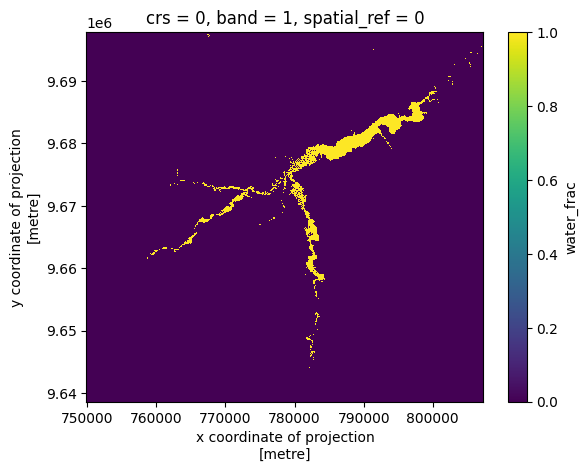

In [102]:
raster, patches, no_data_masks = create_raster_mosaic_combined(
    mosaic_df=mosaic_df,
    ref_date=DATE,
    aoi=aoi,
    **params,
)
raster = process_swot_mask(raster, water_threshold=0.6)
raster.plot()

In [103]:
metrics = ["iou", "f1", "precision", "recall"]
calc_metrics(datasets["ref_mask"], raster, metrics=metrics, binary=True)

,0
iou,0.7518
f1,0.8583
precision,0.9374
recall,0.7915


In [98]:
params = get_filtering_params("Bad removed", "Default filtering")

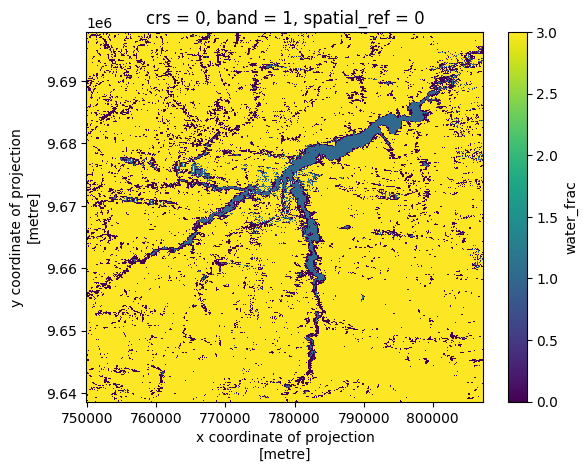

In [99]:
raster2, patches2, no_data_masks2 = create_raster_mosaic_combined(
    mosaic_df=mosaic_df,
    ref_date=DATE,
    aoi=aoi,
    **params,
)
raster2 = process_swot_mask(raster2, water_threshold=0.6)
raster2.plot()

In [100]:
metrics = ["iou", "f1", "precision", "recall"]
calc_metrics(datasets["ref_mask"], raster2, metrics=metrics, binary=True)

,0
iou,0.5837
f1,0.7371
precision,0.6484
recall,0.8540


## Run experiments

In [108]:
import pandas as pd
from tqdm.auto import tqdm

for region, dates in tqdm(sites_dates.items(), desc="Regions"):
    # Open basic info about the region
    base_dir, aoi, mosaic_df = open_roi(region)

    for date in dates:
        # Open datasets for the specific region and date
        datasets = open_datasets(region, date)

        metrics_df = pd.DataFrame()

        # Now, loop through the scenarios
        for i, scenario_a in enumerate(scenarios_A.keys()):
            for j, scenario_b in enumerate(scenarios_B.keys()):
                experiment_name = f"A{i + 1}B{j + 1}"
                params = get_filtering_params(scenario_a, scenario_b)

                raster, patches, no_data_masks = create_raster_mosaic_combined(
                    mosaic_df=mosaic_df,
                    ref_date=date,
                    aoi=aoi,
                    **params,
                )
                pred_mask = process_swot_mask(raster, water_threshold=0.59)

                stats = calc_metrics(
                    datasets["ref_mask"],
                    pred_mask,
                    metrics=metrics,
                    binary=True,
                )
                stats = stats.rename(columns={0: experiment_name})

                metrics_df = (
                    pd.concat([metrics_df, stats], axis=1)
                )

        # After looping through all experiments, save the metrics for this region and date
        output_path = base_dir / date / "results"
        output_path.mkdir(parents=True, exist_ok=True)
        metrics_df.to_parquet(output_path / f"{region}_{date}_metrics.parquet")

Regions:   0%|          | 0/5 [00:00<?, ?it/s]

Reading KML file: /data/swot/output/Northeast/kml/Northeast.kml
Reading KML file: /data/swot/output/Rio_Branco/kml/Rio_Branco.kml


/workspaces/swot/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/swot/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/swot/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/swot/.venv/li

Reading KML file: /data/swot/output/Rio_Madeira/kml/Rio_Madeira.kml
Reading KML file: /data/swot/output/Rio_Negro/kml/Rio_Negro.kml


In [78]:
base_dir

PosixPath('/data/swot/output/Rio_Madeira')

In [79]:
metrics_df

,A1B1,A1B2,A1B3,A1B4,A2B1,A2B2,A2B3,A2B4,A3B1,A3B2,...,A2B3,A2B4,A3B1,A3B2,A3B3,A3B4,A4B1,A4B2,A4B3,A4B4
iou,0.7117,0.7117,0.7117,0.7117,0.4373,0.7548,0.6076,0.7475,0.4373,0.7548,...,0.2589,0.2593,0.2119,0.2297,0.2142,0.2298,0.0,0.0,0.0,0.0
f1,0.8315,0.8315,0.8315,0.8315,0.6085,0.8603,0.7559,0.8555,0.6085,0.8603,...,0.4113,0.4118,0.3497,0.3736,0.3528,0.3737,0.0,0.0,0.0,0.0
precision,0.9123,0.9123,0.9123,0.9123,0.4726,0.8785,0.6892,0.8835,0.4726,0.8785,...,0.3568,0.4434,0.3348,0.3908,0.3406,0.3912,0.0,0.0,0.0,0.0
recall,0.7639,0.7639,0.7639,0.7639,0.8544,0.8428,0.8369,0.8292,0.8544,0.8428,...,0.4855,0.3845,0.3659,0.3579,0.3659,0.3578,0.0,0.0,0.0,0.0


In [ ]:

        output_dir = f"output/analysis/scenario_A_{scenario_A.replace(' ', '_')}_B_{scenario_B.replace(' ', '_')}/"
        output_data = open_output_dir(output_dir)

        sites, dates = open_sites_and_dates(output_data)

        swot_metrics = {}
        for site in tqdm(sites, desc="Sites"):
            swot_metrics[site] = calc_swot_metrics(
                output_data,
                site,
                dates[site],
                exclude_flags=filtering_params["exclude_flags"],
                exclude_bitwise=filtering_params["exclude_bitwise"],
                exclude_geometric=filtering_params["exclude_geometric"],
            )

        output_data.close()

## Open sites and dates

In [ ]:
for A_name, A_filters in scenarios_A.items():
    for B_name, B_filters in scenarios_B.items():
        print(f"Processing Scenario A: {A_name} | Scenario B: {B_name}")
        for site_id, dates in tqdm(sites_dates.items()):
            output_dir = open_output_dir("/data/swot/output", site_id, dates)

            calc_swot_metrics(
                output_dir,
                exclude_flags=B_filters["excclude_flags"],
                exclude_no_data=B_filters["exclude_no_data"],
                exclude_water_area_qual=A_filters["exclude_water_area_qual"]
                if A_filters is not None
                else None,
                recompute=True,
            )